<a href="https://colab.research.google.com/github/prithwirpe/APPENDIX-_/blob/main/RUL_PRED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



In [2]:
# lOADING THE DATASET
import pandas as pd
data = pd.read_csv("train_FD001.txt", sep=" ", header=None)
print(data)

data.head(5)




        0    1       2       3      4       5       6        7        8   \
0        1    1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1        1    2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2        1    3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3        1    4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4        1    5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   
...    ...  ...     ...     ...    ...     ...     ...      ...      ...   
20626  100  196 -0.0004 -0.0003  100.0  518.67  643.49  1597.98  1428.63   
20627  100  197 -0.0016 -0.0005  100.0  518.67  643.54  1604.50  1433.58   
20628  100  198  0.0004  0.0000  100.0  518.67  643.42  1602.46  1428.18   
20629  100  199 -0.0011  0.0003  100.0  518.67  643.23  1605.26  1426.53   
20630  100  200 -0.0032 -0.0005  100.0  518.67  643.85  1600.38  1432.14   

          9   ...       18      19    20   21    22     23     24       25  \
0      14

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [3]:
# CODE FOR DATA CLEANING

data.drop(columns=[26, 27], inplace=True)  # I AM REMOVING  LAST TWO COLUMNS

data.head (5)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
columns = [
    'engine', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1',
    'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7',
    'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13',
    'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19',
    'sensor20', 'sensor21'
]   #GENERTING COLUMN NAMES


data.columns = columns  # RENAMING COLUMN NAMES
data.head (5)


,engine,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
#ANALYZING THE DATA
data.describe()


,engine,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [6]:
# REMOVING CONSTANT COLUMN VALUES

data = data.loc[:, data.nunique() > 1]

data.head(5)

,engine,cycle,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [8]:
#COMPUTING RUL AND ADDING IT IN THE DATA
max_cycle = data.groupby('engine')['cycle'].max()

data = data.merge(max_cycle.to_frame('max_cycle'),
                  left_on='engine',
                  right_index=True)

data['RUL'] = data['max_cycle'] - data['cycle']

data.drop(columns=['max_cycle'], inplace=True)


In [9]:
data.head(5)

,engine,cycle,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [10]:
#PREPRAING THE DATA FOR USING SHAP
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['engine','cycle','RUL'])  # ONLY FEATURES
#X = data.drop(columns=['engine','RUL'])

y = data['RUL'] # ONLY RUL

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#PERFORMING DATA NORMALIZATION
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [11]:
print(X_train.head)
type(X_train)

<bound method NDFrame.head of        setting1  setting2   sensor2   sensor3   sensor4   sensor6   sensor7  \
0      0.419255 -1.033517 -0.367980  0.046640 -0.309543  0.141286 -0.511224   
1     -0.037030 -0.009432 -0.887911  0.523306 -0.455719  0.141286  1.057106   
2     -1.405886  0.673292 -0.547956 -1.820982 -0.758038  0.141286 -0.059906   
3     -0.858344 -0.692155  0.171949 -1.289002 -0.450182  0.141286  1.045823   
4     -0.356430  0.331930  0.011970 -0.532518 -0.422497  0.141286 -0.409677   
...         ...       ...       ...       ...       ...       ...       ...   
16499 -2.318457  0.331930 -0.987898  0.398039 -2.066981  0.141286  0.639637   
16500  1.696854  1.356015 -1.747797 -1.619252 -0.545418  0.141286  1.598687   
16501  0.784283 -0.009432 -0.367980  1.686503  0.722551  0.141286  0.154470   
16502  0.008598  1.356015 -1.507829 -2.035725 -1.410295  0.141286  1.305330   
16503 -0.356430  0.673292 -1.027892  0.009222 -0.848845  0.141286  0.729900   

        sensor8   sen

pandas.core.frame.DataFrame

In [12]:
pip install shap

In [14]:
import shap
X_shap = X_train.sample(200, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

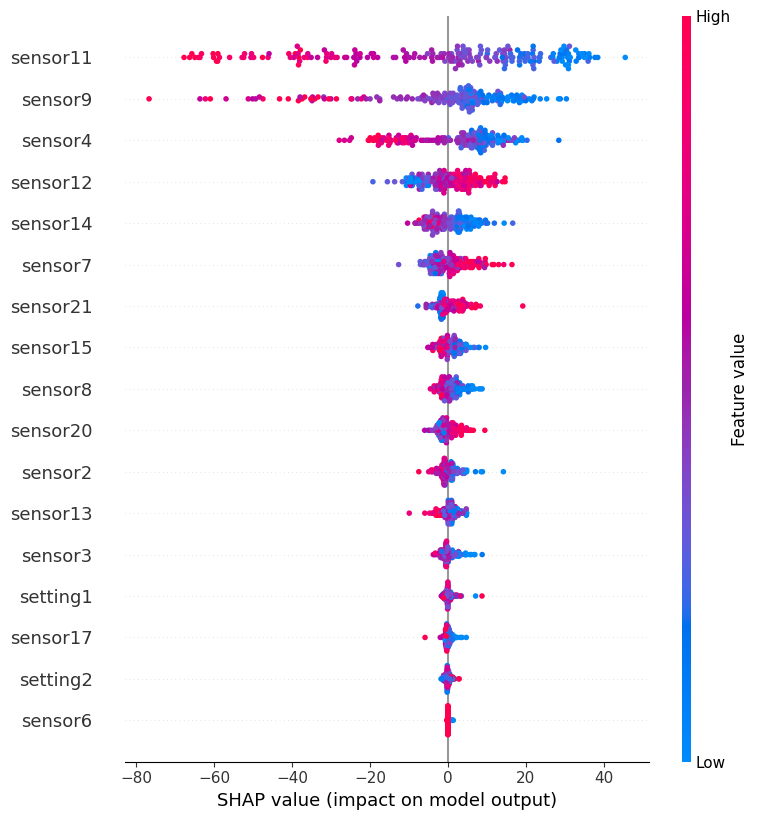

In [18]:
shap.summary_plot(shap_values, X_shap)

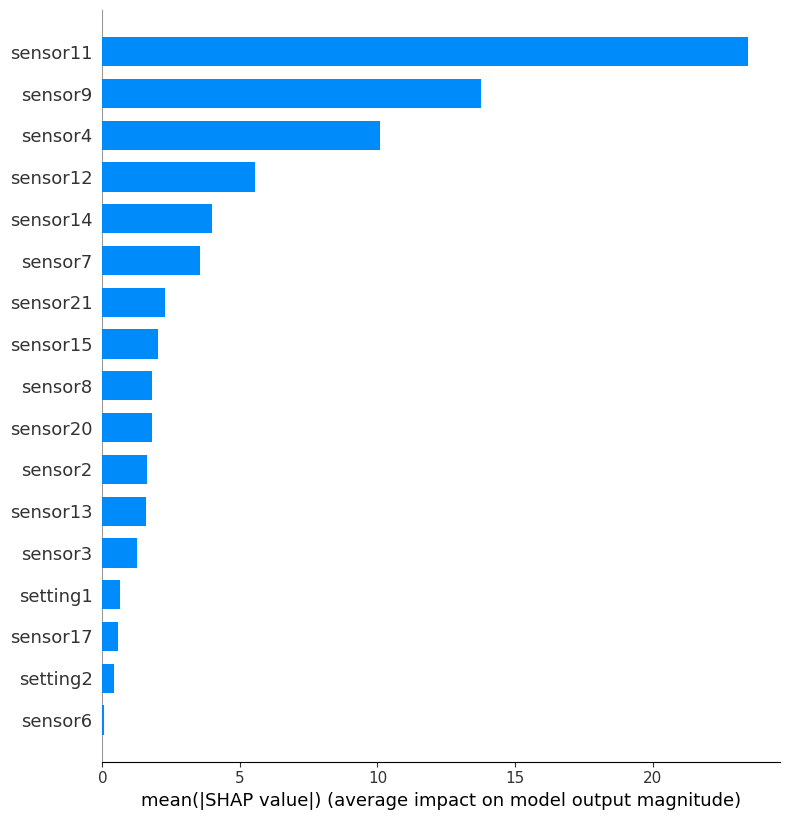

In [17]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [19]:
# NOW SELECTING OPTIMAL NUMBER OF TOP SENSOR DATA TO BE USED FOR TRAINING THE DESIGNED CLASSIFIER

importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

sorted_features = feature_importance['feature'].tolist()
#PRINTING THE TOP FEATURES
print(sorted_features)

['sensor11', 'sensor9', 'sensor4', 'sensor12', 'sensor14', 'sensor7', 'sensor21', 'sensor15', 'sensor8', 'sensor20', 'sensor2', 'sensor13', 'sensor3', 'setting1', 'sensor17', 'setting2', 'sensor6']


In [68]:
# NOW SELECTING OPTIMAL NUMBER OF TOP SENSOR DATA TO BE USED FOR TRAINING THE DESIGNED CLASSIFIER

importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

sorted_features = feature_importance['feature'].tolist()
#PRINTING THE TOP FEATURES
print(sorted_features)

['sensor11', 'sensor9', 'sensor4', 'sensor12', 'sensor14', 'sensor7', 'sensor21', 'sensor15', 'sensor8', 'sensor20', 'sensor2', 'sensor13', 'sensor3', 'setting1', 'sensor17', 'setting2', 'sensor6']


In [20]:
#
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

mae_list = []

for k in range(1, len(sorted_features)+1):

    top_features = sorted_features[:k]

    X_k = X[top_features]

    X_train1, X_test1, y_train1, y_test1 = train_test_split(
        X_k, y,
        test_size=0.2,
        random_state=42
    )  #x-K IS SORTED TOP FEATURES AND y is RUL  TARGET

    model1 = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )


    model1.fit(X_train1, y_train1)

    y_pred1 = model1.predict(X_test1)

    mae1 = mean_absolute_error(y_test1, y_pred1)

    mae_list.append(mae1)

    print(f"Top {k} Featurs → MAE = {mae1}")



Top 1 Featurs → MAE = 36.708143391417835
Top 2 Featurs → MAE = 36.27126029082581
Top 3 Featurs → MAE = 32.69346983280834
Top 4 Featurs → MAE = 31.18480978919312
Top 5 Featurs → MAE = 30.858426217591468
Top 6 Featurs → MAE = 30.47192633874485
Top 7 Featurs → MAE = 30.261001938454083
Top 8 Featurs → MAE = 30.06753695178095
Top 9 Featurs → MAE = 29.92215531863339
Top 10 Featurs → MAE = 29.81426338744851
Top 11 Featurs → MAE = 29.69264598982312
Top 12 Featurs → MAE = 29.63551126726436
Top 13 Featurs → MAE = 29.498163314756486
Top 14 Featurs → MAE = 29.57329658347468
Top 15 Featurs → MAE = 29.505190210806884
Top 16 Featurs → MAE = 29.59688514659559
Top 17 Featurs → MAE = 29.559958807850737


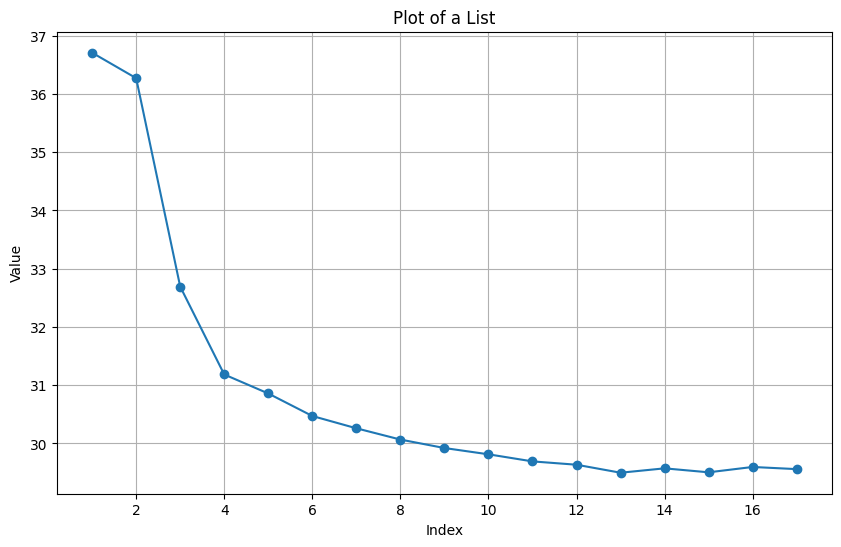

17


In [29]:
import matplotlib.pyplot as plt

# Assuming you have a list named 'my_list' you want to plot
# For demonstration, let's use the 'mae_list' from our previous steps
my_list = mae_list
T= list(range(1,18))
plt.figure(figsize=(10, 6))
plt.plot(T, my_list, marker='o')
plt.title('Plot of a List')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()
print(len(sorted_features) )

In [30]:
# SELECTING OPTIMAL NO OF FEATURES
# COMPUTING:  DELTA E(k)=E(k−1)−E(k)
# K IS OPTIMAL: WHEN, K<=O  OR K<.OOO1

import numpy as np

E = np.array(mae_list)

delta_E = E[:-1] - E[1:]

print("Delta E values:", delta_E)

threshold = 0.0001

best_k = None

for i, d in enumerate(delta_E):
    if d <= 0 or d < threshold:
        best_k = i + 1   #
        break

if best_k is None:
    best_k = len(E)

print("Selected optimal number of sensors:", best_k)

Delta E values: [ 0.4368831   3.57779046  1.50866004  0.32638357  0.38649988  0.2109244
  0.19346499  0.14538163  0.10789193  0.1216174   0.05713472  0.13734795
 -0.07513327  0.06810637 -0.09169494  0.03692634]
Selected number of sensors (k): 13


##Novelty: The proposed XAI-based optimal feature selection technique

In [21]:
pd.DataFrame(data.head(25))


,engine,cycle,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
5,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669,186
6,1,7,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,392,39.10,23.3774,185
7,1,8,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,391,38.97,23.3106,184
8,1,9,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,9046.46,47.29,521.79,2388.05,8125.69,8.3728,392,39.05,23.4066,183
9,1,10,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,9051.70,47.03,521.79,2388.06,8129.38,8.4286,393,38.95,23.4694,182


In [22]:
pd.DataFrame(X.head(25))


,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
5,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,391,38.98,23.3669
6,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,392,39.10,23.3774
7,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,391,38.97,23.3106
8,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,9046.46,47.29,521.79,2388.05,8125.69,8.3728,392,39.05,23.4066
9,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,9051.70,47.03,521.79,2388.06,8129.38,8.4286,393,38.95,23.4694


In [26]:
#X CONTAINS DATA, y CONTAINS RUL DATA
# NOW SELECTING ONLY OPTIMAL FEATURES FROM X, I.E. 13 TOP FEATURES

X_OPT= X[['sensor11', 'sensor9', 'sensor4', 'sensor12', 'sensor14', 'sensor7', 'sensor21', 'sensor15', 'sensor8', 'sensor20', 'sensor2', 'sensor13', 'sensor3']]
# X_OPT CONTINS OPTIMAL FEATURES
print(X_OPT.head(5))
y.head(5)


   sensor11  sensor9  sensor4  sensor12  sensor14  sensor7  sensor21  \
0     47.47  9046.19  1400.60    521.66   8138.62   554.36   23.4190   
1     47.49  9044.07  1403.14    522.28   8131.49   553.75   23.4236   
2     47.27  9052.94  1404.20    522.42   8133.23   554.26   23.3442   
3     47.13  9049.48  1401.87    522.86   8133.83   554.45   23.3739   
4     47.28  9055.15  1406.22    522.19   8133.80   554.00   23.4044   

   sensor15  sensor8  sensor20  sensor2  sensor13  sensor3  
0    8.4195  2388.06     39.06   641.82   2388.02  1589.70  
1    8.4318  2388.04     39.00   642.15   2388.07  1591.82  
2    8.4178  2388.08     38.95   642.35   2388.03  1587.99  
3    8.3682  2388.11     38.88   642.35   2388.08  1582.79  
4    8.4294  2388.06     38.90   642.37   2388.04  1582.85  


,RUL
0,191
1,190
2,189
3,188
4,187


In [27]:
X_OPT.head(5)


,sensor11,sensor9,sensor4,sensor12,sensor14,sensor7,sensor21,sensor15,sensor8,sensor20,sensor2,sensor13,sensor3
0,47.47,9046.19,1400.60,521.66,8138.62,554.36,23.4190,8.4195,2388.06,39.06,641.82,2388.02,1589.70
1,47.49,9044.07,1403.14,522.28,8131.49,553.75,23.4236,8.4318,2388.04,39.00,642.15,2388.07,1591.82
2,47.27,9052.94,1404.20,522.42,8133.23,554.26,23.3442,8.4178,2388.08,38.95,642.35,2388.03,1587.99
3,47.13,9049.48,1401.87,522.86,8133.83,554.45,23.3739,8.3682,2388.11,38.88,642.35,2388.08,1582.79
4,47.28,9055.15,1406.22,522.19,8133.80,554.00,23.4044,8.4294,2388.06,38.90,642.37,2388.04,1582.85


In [28]:
y.head(5)

,RUL
0,191
1,190
2,189
3,188
4,187


In [30]:
#DATA NORMALIZATION
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_OPT_N = scaler.fit_transform(X_OPT)
X_OPT_N = pd.DataFrame(X_OPT_N, columns=X_OPT.columns)
X_OPT_N.head(5)

#X_OPT_N IS THE NORMALIZED DATA

,sensor11,sensor9,sensor4,sensor12,sensor14,sensor7,sensor21,sensor15,sensor8,sensor20,sensor2,sensor13,sensor3
0,-0.266467,-0.862813,-0.925936,0.334262,-0.269071,1.121141,1.194427,-0.603816,-0.516338,1.348493,-1.721725,-1.058890,-0.134255
1,-0.191583,-0.958818,-0.643726,1.174899,-0.642845,0.431930,1.236922,-0.275852,-0.798093,1.016528,-1.061780,-0.363646,0.211528
2,-1.015303,-0.557139,-0.525953,1.364721,-0.551629,1.008155,0.503423,-0.649144,-0.234584,0.739891,-0.661813,-0.919841,-0.413166
3,-1.539489,-0.713826,-0.784831,1.961302,-0.520176,1.222827,0.777792,-1.971665,0.188048,0.352598,-0.661813,-0.224597,-1.261314
4,-0.977861,-0.457059,-0.301518,1.052871,-0.521748,0.714393,1.059552,-0.339845,-0.516338,0.463253,-0.621816,-0.780793,-1.251528


# NOW DESIGNING CLASSIFER MODELS AND TESTING ON [NON WINDOWED] DATA, I.E., X_OPT_N


In [34]:
# NOW DESIGNING CLASSIFER MODELS AND TESTING ON [NON WINDOWED] DATA, I.E., X_OPT_N

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_OPT_N, y, test_size=0.2,random_state=42)


# TESTING ANN-BASED REGRESSION

import time
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(
    hidden_layer_sizes=(128, 64,32),
    activation='relu',
    max_iter=55,
    random_state=42
)

start_train = time.time()

ann_model.fit(X_train, y_train)

train_time_ann = time.time() - start_train


start_inf = time.time()

y_pred_ann = ann_model.predict(X_test)

infer_time_ann = time.time() - start_inf



mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN MSE:", mse_ann)
print("ANN RMSE:", rmse_ann)
print("ANN R2:", r2_ann)
print("ANN Training Time:", train_time_ann)
print("ANN Inference Time:", infer_time_ann)

ANN MSE: 1658.7529622927977
ANN RMSE: 40.72779103134367
ANN R2: 0.6369386420207332
ANN Training Time: 21.379295825958252
ANN Inference Time: 0.01239776611328125


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (55) reached and the optimization hasn't converged yet.
  warnings.warn(


In [35]:
# LOGISTIC REGRESSION  [ WITH OUT WINDOWING]

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time

lr_model = LinearRegression()

start_train = time.time()
lr_model.fit(X_train, y_train)
train_time_lr = time.time() - start_train


start_inf = time.time()
y_pred_lr = lr_model.predict(X_test)
infer_time_lr = time.time() - start_inf


mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("LR MSE:", mse_lr)
print("LR RMSE:", rmse_lr)
print("LR MAE:", mae_lr)
print("LR R2:", r2_lr)
print("LR Training Time:", train_time_lr)
print("LR Inference Time:", infer_time_lr)

LR MSE: 1967.8206001194874
LR RMSE: 44.36012398674611
LR MAE: 34.04813903573378
LR R2: 0.5692911267803084
LR Training Time: 0.0336916446685791
LR Inference Time: 0.002015352249145508


In [36]:
#SVM REGRESSION

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time


svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)


start_train = time.time()

svr_model.fit(X_train, y_train)

train_time_svr = time.time() - start_train


start_inf = time.time()

y_pred_svr = svr_model.predict(X_test)

infer_time_svr = time.time() - start_inf


mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)


print("SVR MSE:", mse_svr)
print("SVR RMSE:", rmse_svr)
print("SVR MAE:", mae_svr)
print("SVR R2:", r2_svr)
print("SVR Training Time:", train_time_svr)
print("SVR Inference Time:", infer_time_svr)

SVR MSE: 1726.9438978876897
SVR RMSE: 41.55651450600362
SVR MAE: 29.094840637094528
SVR R2: 0.6220132768568107
SVR Training Time: 41.03686165809631
SVR Inference Time: 4.509219646453857


# USING WINDOWING   

In [38]:
# USING WINDOWING [SEQUENCE DATA]

In [47]:

#WINDOWING [USING WINDOWING]
from sklearn.preprocessing import StandardScaler
feature_cols = [
    'sensor11', 'sensor9', 'sensor4',
           'sensor12', 'sensor14', 'sensor7',
    'sensor21', 'sensor15', 'sensor8', 'sensor20', 'sensor2', 'sensor13',
    'sensor3'
]

scaler = StandardScaler()

data[feature_cols] = scaler.fit_transform(data[feature_cols])

import numpy as np

WINDOW_SIZE = 5
STRIDE = 1

def create_windows(dataframe, feature_cols,
                   target_col='RUL',
                   window_size=5,
                   stride=1):

    X_windows = []
    y_windows = []


    for engine_id, group in dataframe.groupby('engine'):

        group = group.sort_values('cycle')

        X_engine = group[feature_cols].values
        y_engine = group[target_col].values


        for i in range(0,len(group) - window_size + 1,stride):

            X_win = X_engine[i : i + window_size]
            y_win = y_engine[i + window_size - 1]  # last timestep RUL

            X_windows.append(X_win)
            y_windows.append(y_win)

    return np.array(X_windows), np.array(y_windows)

In [54]:
# WINDOWING DATA



X_windowed, y_windowed = create_windows(
    data,
    feature_cols,
    window_size=5,
    stride=1
)

print("X shape:", X_windowed.shape)
print("y shape:", y_windowed.shape)
print("One sample shape:", X_windowed[0].shape)



X shape: (20231, 5, 13)
y shape: (20231,)
One sample shape: (5, 13)


In [55]:
X_windowed[1]

array([[-0.19158293, -0.95881761, -0.64372587,  1.17489932, -0.64284474,
         0.43193018,  1.23692196, -0.27585181, -0.798093  ,  1.01652793,
        -1.06177971, -0.363646  ,  0.21152849],
       [-1.0153033 , -0.55713925, -0.52595315,  1.36472069, -0.55162928,
         1.00815526,  0.50342281, -0.64914404, -0.23458381,  0.73989059,
        -0.66181262, -0.91984139, -0.41316559],
       [-1.53948899, -0.71382551, -0.78483092,  1.96130213, -0.52017567,
         1.22282735,  0.77779214, -1.97166509,  0.18804808,  0.3525983 ,
        -0.66181262, -0.22459715, -1.26131421],
       [-0.97786146, -0.45705929, -0.30151835,  1.0528713 , -0.52174835,
         0.71439345,  1.05955189, -0.33984476, -0.51633841,  0.46325324,
        -0.62181592, -0.78079254, -1.25152788],
       [-1.42716349, -0.7047685 , -1.1737031 ,  0.36137918, -0.57154989,
         1.47139503,  0.71312597, -0.83579016, -1.07984759,  0.90587299,
        -1.16177148, -0.91984139, -0.98729697]])

In [57]:
y_windowed[1]

np.int64(186)

In [45]:
y_windowed[1]

np.int64(186)

In [58]:
# DATA SPLITTING FOR TRAINING ND TESTING
from sklearn.model_selection import train_test_split

X_train_W, X_test_W, y_train_W, y_test_W = train_test_split(
    X_windowed,
    y_windowed,
    test_size=0.2,
    random_state=42
)

In [61]:
#LSTM MODEL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time


lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train_W.shape[1], X_train_W.shape[2])),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)




start_train = time.time()

history = lstm_model.fit(
    X_train_W, y_train_W,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
        verbose=1
)

train_time_lstm = time.time() - start_train


start_inf = time.time()

y_pred_lstm = lstm_model.predict(X_test_W).flatten()

infer_time_lstm = time.time() - start_inf



mse_lstm = mean_squared_error(y_test_W, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test_W, y_pred_lstm)
r2_lstm = r2_score(y_test_W, y_pred_lstm)


print("LSTM MSE:", mse_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)
print("LSTM R2:", r2_lstm)
print("LSTM Training Time:", train_time_lstm)
print("LSTM Inference Time:", infer_time_lstm)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 11978.6826 - val_loss: 2603.9150
Epoch 2/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 1958.8196 - val_loss: 1712.9498
Epoch 3/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1612.1289 - val_loss: 1670.8422
Epoch 4/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1513.4491 - val_loss: 1641.3340
Epoch 5/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1532.8663 - val_loss: 1583.2754
Epoch 6/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1470.9535 - val_loss: 1571.1666
Epoch 7/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1505.5997 - val_loss: 1563.1082
Epoch 8/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1452.7373 - val_loss: 1524.9905
Epoch 9/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1433.3898 - val_loss: 1524.5437
Epoch 10/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1442.3334 - val_loss: 1554.0394
Epoch 11/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1368.3553 - val_loss: 15

In [64]:
#A HYBRID CNN-LSTM MODEL WITH MULTIHEAD ATTENTION

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D,Concatenate, Bidirectional, LSTM
from tensorflow.keras.layers import MultiHeadAttention,LayerNormalization,GlobalAveragePooling1D, Dense, Dropout, Add

from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time



inputs = Input(shape=(X_train_W.shape[1], X_train_W.shape[2]))



b1 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
b1 = MaxPooling1D(pool_size=2)(b1)

b2 = Conv1D(64, kernel_size=5, activation='relu', padding='same')(inputs)
b2 = MaxPooling1D(pool_size=2)(b2)

b3 = Conv1D(64, kernel_size=7, activation='relu', padding='same')(inputs)
b3 = MaxPooling1D(pool_size=2)(b3)

x = Concatenate()([b1, b2, b3])


c1 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
c1 = MaxPooling1D(pool_size=2)(c1)

c2 = Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
c2 = MaxPooling1D(pool_size=2)(c2)

c3 = Conv1D(128, kernel_size=7, activation='relu', padding='same')(x)
c3 = MaxPooling1D(pool_size=2)(c3)

x = Concatenate()([c1, c2, c3])


x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(32, return_sequences=True))(x)


attn_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x, x)

x = Add()([x, attn_output])
x = LayerNormalization()(x)



x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

outputs = Dense(1)(x)



model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()




start_train = time.time()

history = model.fit(
    X_train_W, y_train_W,
    epochs=65,
    batch_size=32,
    validation_split=0.2,
       verbose=1
)

train_time = time.time() - start_train


# ===============================
# INFERENCE
# ===============================
start_inf = time.time()

y_pred = model.predict(X_test_W).flatten()

infer_time = time.time() - start_inf


# ===============================
# METRICS
# ===============================
mse = mean_squared_error(y_test_W, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_W, y_pred)
r2 = r2_score(y_test_W, y_pred)


# ===============================
# RESULTS
# ===============================
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Training Time:", train_time)
print("Inference Time:", infer_time)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 5, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 5, 64)     │      2,560 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 5, 64)     │      4,224 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 5, 64)     │      5,888 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 2, 64)     │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 2, 64)     │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 2, 64)     │          0 │ conv1d_8[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 2, 192)    │          0 │ max_pooling1d_6[… │
│ (Concatenate)       │                   │            │ max_pooling1d_7[… │
│                     │                   │            │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2, 128)    │     73,856 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 2, 128)    │    123,008 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 2, 128)    │    172,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 1, 128)    │          0 │ conv1d_9[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 1, 128)    │          0 │ conv1d_10[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 1, 128)    │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1, 384)    │          0 │ max_pooling1d_9[… │
│ (Concatenate)       │                   │            │ max_pooling1d_10… │
│                     │                   │            │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 1, 128)    │    229,888 │ concatenate_3[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 1, 64)     │     41,216 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 64)     │     33,216 │ bidirectional_3[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_3[

 Total params: 692,417 (2.64 MB)

 Trainable params: 692,417 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - loss: 6178.5708 - val_loss: 1723.4675
Epoch 2/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1762.3079 - val_loss: 1701.5692
Epoch 3/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1737.5953 - val_loss: 1725.9996
Epoch 4/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 1691.6266 - val_loss: 1641.7792
Epoch 5/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 1547.9009 - val_loss: 1664.5369
Epoch 6/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 1462.0934 - val_loss: 1686.8551
Epoch 7/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - loss: 1311.6212 - val_loss: 1698.4062
Epoch 8/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 1200.7362 - val_loss: 1832.2288
Epoch 9/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 1061.2183 - val_loss: 1612.3140
Epoch 10/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 950.4855 - val_loss: 1579.4221
Epoch 11/40
405/405 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - los

ValueError: Input 0 of layer "functional_4" is incompatible with the layer: expected shape=(None, 5, 13), found shape=(32, 13)

In [65]:
# ===============================
# INFERENCE
# ===============================
start_inf = time.time()

y_pred = model.predict(X_test_W)

infer_time = time.time() - start_inf


# ===============================
# METRICS
# ===============================
mse = mean_squared_error(y_test_W, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_W, y_pred)
r2 = r2_score(y_test_W, y_pred)


# ===============================
# RESULTS
# ===============================
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Training Time:", train_time)
print("Inference Time:", infer_time)

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
MSE: 1314.8046875
RMSE: 36.260235623889706
MAE: 25.01537322998047
R2: 0.7155414819717407
Training Time: 697.3120937347412
Inference Time: 2.3819146156311035


# ### DESIGING A CNN-BILSTM BASED MODEL WITH MULTIHEAD ATTENTION, WITH A NOVEL: INPUT ENHANCEMENT LAYER.

# MODEL HAS: MULTISCLAE CNN BLOCKS, BILSTM BLOCKS, MULTIHEAD ATTENTION BLOCK, DENSE LAYER

In [82]:
import numpy as np

# feature_importance already computed earlier
importance_selected = feature_importance[
    feature_importance['feature'].isin(feature_cols)
]['importance'].values


def shap_val(x):
    shap_weights = x/ np.sum(x)
    return shap_weights


shap_weights = shap_val(importance_selected)



print("SHAP weights length:", len(shap_weights))
print("SHAP weights:", shap_weights)




# Now dataset size: 5x13   ....   so for enhancing it with we will mutiply with
# ehnacement matrix: 13x5   ...
import numpy as np
E_Mat = np.vstack([shap_weights]*5)
print('E_Mat')
print(E_Mat.shape)
print(E_Mat)

SHAP weights length: 13
SHAP weights: [0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
 0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
 0.01744871]
E_Mat
(5, 13)
[[0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
  0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
  0.01744871]
 [0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
  0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
  0.01744871]
 [0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
  0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
  0.01744871]
 [0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
  0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
  0.01744871]
 [0.32226591 0.18906134 0.13853746 0.07638577 0.05474836 0.04879848
  0.03129452 0.0277422  0.02503704 0.02465234 0.0223355  0.02169237
  0.01744871]]


In [83]:
# A HYBRID CNN-LSTM MODEL WITH MULTIHEAD ATTENTION
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Concatenate,
    Bidirectional, LSTM,
    MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Dense, Dropout, Add, Layer
)
from tensorflow.keras.models import Model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time



# SHAP INPUT ENHANCEMENT LAYER

class SHAPInputEnhancement(Layer):

    def __init__(self, shap_weights):
        super().__init__()
        self.shap_weights = tf.constant(
            shap_weights,
            dtype=tf.float32
        )

    def call(self, inputs):
        return inputs * self.shap_weights



inputs = Input(shape=(X_train_W.shape[1], X_train_W.shape[2]))

x = SHAPInputEnhancement(E_Mat)(inputs)



b1 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
b1 = MaxPooling1D(pool_size=2)(b1)

b2 = Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
b2 = MaxPooling1D(pool_size=2)(b2)

b3 = Conv1D(64, kernel_size=7, activation='relu', padding='same')(x)
b3 = MaxPooling1D(pool_size=2)(b3)

x = Concatenate()([b1, b2, b3])


c1 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
c1 = MaxPooling1D(pool_size=2)(c1)

c2 = Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
c2 = MaxPooling1D(pool_size=2)(c2)

c3 = Conv1D(128, kernel_size=7, activation='relu', padding='same')(x)
c3 = MaxPooling1D(pool_size=2)(c3)

x = Concatenate()([c1, c2, c3])



x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(32, return_sequences=True))(x)



attn_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x, x)

x = Add()([x, attn_output])
x = LayerNormalization()(x)


x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

outputs = Dense(1)(x)



model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()



start_train = time.time()

history = model.fit(
    X_train_W, y_train_W,
    epochs=65,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

train_time = time.time() - start_train



start_inf = time.time()

y_pred = model.predict(X_test_W).flatten()

infer_time = time.time() - start_inf



mse = mean_squared_error(y_test_W, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_W, y_pred)
r2 = r2_score(y_test_W, y_pred)


# RESULTS

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Training Time:", train_time)
print("Inference Time:", infer_time)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 5, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shap_input_enhance… │ (None, 5, 13)     │          0 │ input_layer_6[0]… │
│ (SHAPInputEnhancem… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 5, 64)     │      2,560 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 5, 64)     │      4,224 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 5, 64)     │      5,888 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 2, 64)     │          0 │ conv1d_12[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 2, 64)     │          0 │ conv1d_13[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 2, 64)     │          0 │ conv1d_14[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 2, 192)    │          0 │ max_pooling1d_12… │
│ (Concatenate)       │                   │            │ max_pooling1d_13… │
│                     │                   │            │ max_pooling1d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 2, 128)    │     73,856 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 2, 128)    │    123,008 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 2, 128)    │    172,160 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 1, 128)    │          0 │ conv1d_15[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_16    │ (None, 1, 128)    │          0 │ conv1d_16[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_17    │ (None, 1, 128)    │          0 │ conv1d_17[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 1, 384)    │          0 │ max_pooling1d_15… │
│ (Concatenate)       │                   │            │ max_pooling1d_16… │
│                     │                   │            │ max_pooling1d_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 1, 128)    │    229,888 │ concatenate_5[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 1, 64)     │     41,216 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │                 

 Total params: 692,417 (2.64 MB)

 Trainable params: 692,417 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 6544.7998 - val_loss: 1725.3590
Epoch 2/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1822.3738 - val_loss: 1734.2625
Epoch 3/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1773.7107 - val_loss: 1653.6992
Epoch 4/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 1773.8081 - val_loss: 1671.0641
Epoch 5/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 1631.7422 - val_loss: 1628.1229
Epoch 6/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 1646.6561 - val_loss: 1673.8608
Epoch 7/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 1611.7035 - val_loss: 1605.8163
Epoch 8/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 1615.7256 - val_loss: 1571.8403
Epoch 9/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 1538.5682 - val_loss: 1565.7823
Epoch 10/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 1416.5292 - val_loss: 1581.4440
Epoch 11/65
405/405 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - lo

# TESTING ON UNKNOWN DATA

In [86]:
test_DATA= pd.read_csv("test_FD001.txt",sep=" ",header=None )
print(test_DATA.shape)
test_DATA.head()

(13096, 28)


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN


In [87]:

test_DATA.drop(columns=[26, 27], inplace=True)  # I AM REMOVING  LAST TWO COLUMNS

test_DATA.head (5)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [88]:
columns = [
    'engine', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1',
    'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7',
    'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13',
    'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19',
    'sensor20', 'sensor21'
]   #GENERTING COLUMN NAMES


test_DATA.columns = columns  # RENAMING COLUMN NAMES
test_DATA.head (5)


,engine,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [89]:
test_DATA = test_DATA.loc[:, test_DATA.nunique() > 1]

test_DATA.head(5)

,engine,cycle,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130


In [102]:
# SORTING DATA ENGINE AND CYCLE WISE
test_DATA = test_DATA.sort_values(['engine', 'cycle'])

# GETTING LAST FIVE ROWS
last_samples_df = test_DATA.groupby('engine').tail(5)


last_samples_df = last_samples_df.reset_index(drop=True)

print(type(last_samples_df))


<class 'pandas.core.frame.DataFrame'>


In [103]:
last_samples_df.head()
last_samples_df

,engine,cycle,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,27,-0.0007,0.0001,642.08,1586.65,1400.31,21.61,554.35,2388.09,9046.10,47.34,521.82,2388.02,8127.24,8.4494,392,38.87,23.3931
1,1,28,0.0022,0.0005,641.93,1594.25,1401.29,21.61,553.56,2388.07,9055.56,47.05,521.84,2388.07,8134.89,8.4470,392,38.83,23.3502
2,1,29,0.0014,0.0001,641.95,1587.15,1398.11,21.61,554.15,2388.08,9046.11,47.42,522.39,2388.07,8133.13,8.4212,392,39.02,23.3621
3,1,30,-0.0025,0.0004,642.79,1585.72,1400.97,21.61,554.10,2388.09,9047.45,47.40,521.78,2388.10,8134.79,8.4110,391,39.09,23.4069
4,1,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,100,194,0.0049,0.0000,643.24,1599.45,1415.79,21.61,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394,38.65,23.1974
496,100,195,-0.0011,-0.0001,643.22,1595.69,1422.05,21.61,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395,38.57,23.2771
497,100,196,-0.0006,-0.0003,643.44,1593.15,1406.82,21.61,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395,38.62,23.2051
498,100,197,-0.0038,0.0001,643.26,1594.99,1419.36,21.61,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395,38.66,23.2699


In [104]:
print(last_samples_df.shape)

(500, 19)


In [106]:
last_samples_df_F=last_samples_df.drop(columns=['engine','cycle'])
last_samples_df_F.head()

,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,-0.0007,0.0001,642.08,1586.65,1400.31,21.61,554.35,2388.09,9046.10,47.34,521.82,2388.02,8127.24,8.4494,392,38.87,23.3931
1,0.0022,0.0005,641.93,1594.25,1401.29,21.61,553.56,2388.07,9055.56,47.05,521.84,2388.07,8134.89,8.4470,392,38.83,23.3502
2,0.0014,0.0001,641.95,1587.15,1398.11,21.61,554.15,2388.08,9046.11,47.42,522.39,2388.07,8133.13,8.4212,392,39.02,23.3621
3,-0.0025,0.0004,642.79,1585.72,1400.97,21.61,554.10,2388.09,9047.45,47.40,521.78,2388.10,8134.79,8.4110,391,39.09,23.4069
4,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552


In [110]:
TEST_OPT= last_samples_df_F[['sensor11', 'sensor9', 'sensor4', 'sensor12', 'sensor14', 'sensor7', 'sensor21', 'sensor15', 'sensor8', 'sensor20', 'sensor2', 'sensor13', 'sensor3']]
# TEST_OPT CONTINS OPTIMAL FEATURES
print(TEST_OPT.head(5))
TEST_OPT.head(5)

   sensor11  sensor9  sensor4  sensor12  sensor14  sensor7  sensor21  \
0     47.34  9046.10  1400.31    521.82   8127.24   554.35   23.3931   
1     47.05  9055.56  1401.29    521.84   8134.89   553.56   23.3502   
2     47.42  9046.11  1398.11    522.39   8133.13   554.15   23.3621   
3     47.40  9047.45  1400.97    521.78   8134.79   554.10   23.4069   
4     47.23  9056.40  1398.91    521.79   8130.11   554.42   23.3552   

   sensor15  sensor8  sensor20  sensor2  sensor13  sensor3  
0    8.4494  2388.09     38.87   642.08   2388.02  1586.65  
1    8.4470  2388.07     38.83   641.93   2388.07  1594.25  
2    8.4212  2388.08     39.02   641.95   2388.07  1587.15  
3    8.4110  2388.09     39.09   642.79   2388.10  1585.72  
4    8.4024  2388.08     38.81   642.58   2388.06  1581.22  


,sensor11,sensor9,sensor4,sensor12,sensor14,sensor7,sensor21,sensor15,sensor8,sensor20,sensor2,sensor13,sensor3
0,47.34,9046.10,1400.31,521.82,8127.24,554.35,23.3931,8.4494,2388.09,38.87,642.08,2388.02,1586.65
1,47.05,9055.56,1401.29,521.84,8134.89,553.56,23.3502,8.4470,2388.07,38.83,641.93,2388.07,1594.25
2,47.42,9046.11,1398.11,522.39,8133.13,554.15,23.3621,8.4212,2388.08,39.02,641.95,2388.07,1587.15
3,47.40,9047.45,1400.97,521.78,8134.79,554.10,23.4069,8.4110,2388.09,39.09,642.79,2388.10,1585.72
4,47.23,9056.40,1398.91,521.79,8130.11,554.42,23.3552,8.4024,2388.08,38.81,642.58,2388.06,1581.22


In [113]:
#DATA NORMALIZATION
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# normalize
TEST_OPT_N = scaler.fit_transform(TEST_OPT)

# convert back to dataframe
TEST_OPT_N = pd.DataFrame(TEST_OPT_N, columns=TEST_OPT.columns)

TEST_OPT_N.head()



,sensor11,sensor9,sensor4,sensor12,sensor14,sensor7,sensor21,sensor15,sensor8,sensor20,sensor2,sensor13,sensor3
0,-0.972817,-0.836538,-1.187380,0.784270,-0.811003,1.318707,1.225115,0.015367,-0.331244,0.526136,-1.459364,-1.372765,-0.814604
1,-2.137723,-0.380344,-1.070714,0.812865,-0.392292,0.396893,0.793061,-0.054776,-0.621809,0.288065,-1.779831,-0.634402,0.514768
2,-0.651464,-0.836055,-1.449286,1.599222,-0.488623,1.085337,0.912908,-0.808814,-0.476527,1.418901,-1.737103,-0.634402,-0.727146
3,-0.731802,-0.771436,-1.108809,0.727080,-0.397765,1.026994,1.364097,-1.106922,-0.331244,1.835524,0.057513,-0.191384,-0.977278
4,-1.414678,-0.339836,-1.354047,0.741378,-0.653918,1.400387,0.843417,-1.358268,-0.476527,0.169030,-0.391141,-0.782074,-1.764406


In [121]:
chunk_size = 5

datasets = []

for i in range(0, len(TEST_OPT_N), chunk_size):
    chunk = TEST_OPT_N.iloc[i:i+chunk_size]

    # only keep full chunks of 5 rows
    if len(chunk) == chunk_size:
        datasets.append(chunk.reset_index(drop=True))

print("Number of datasets:", len(datasets))

Number of datasets: 100


In [123]:
import pandas as pd


rul_df = pd.read_csv("RUL_FD001.txt", header=None)


rul_df.columns = ['RUL']

print(rul_df.shape)
rul_df.head()
rul_df.tail()


(100, 1)


,RUL
95,137
96,82
97,59
98,117
99,20


In [127]:
print(datasets)
#y_pred_u = model.predict(datasets)

[   sensor11   sensor9   sensor4  sensor12  sensor14   sensor7  sensor21  \
0 -0.972817 -0.836538 -1.187380  0.784270 -0.811003  1.318707  1.225115   
1 -2.137723 -0.380344 -1.070714  0.812865 -0.392292  0.396893  0.793061   
2 -0.651464 -0.836055 -1.449286  1.599222 -0.488623  1.085337  0.912908   
3 -0.731802 -0.771436 -1.108809  0.727080 -0.397765  1.026994  1.364097   
4 -1.414678 -0.339836 -1.354047  0.741378 -0.653918  1.400387  0.843417   

   sensor15   sensor8  sensor20   sensor2  sensor13   sensor3  
0  0.015367 -0.331244  0.526136 -1.459364 -1.372765 -0.814604  
1 -0.054776 -0.621809  0.288065 -1.779831 -0.634402  0.514768  
2 -0.808814 -0.476527  1.418901 -1.737103 -0.634402 -0.727146  
3 -1.106922 -0.331244  1.835524  0.057513 -0.191384 -0.977278  
4 -1.358268 -0.476527  0.169030 -0.391141 -0.782074 -1.764406  ,    sensor11   sensor9   sensor4  sensor12  sensor14   sensor7  sensor21  \
0 -0.330110 -0.841842 -0.486189  0.541214 -0.757364  0.735281  0.192819   
1 -0.651464 -

In [132]:
datasets_list = [pd.DataFrame(d) for d in datasets]

datasets_list[0].head()

,sensor11,sensor9,sensor4,sensor12,sensor14,sensor7,sensor21,sensor15,sensor8,sensor20,sensor2,sensor13,sensor3
0,-0.972817,-0.836538,-1.187380,0.784270,-0.811003,1.318707,1.225115,0.015367,-0.331244,0.526136,-1.459364,-1.372765,-0.814604
1,-2.137723,-0.380344,-1.070714,0.812865,-0.392292,0.396893,0.793061,-0.054776,-0.621809,0.288065,-1.779831,-0.634402,0.514768
2,-0.651464,-0.836055,-1.449286,1.599222,-0.488623,1.085337,0.912908,-0.808814,-0.476527,1.418901,-1.737103,-0.634402,-0.727146
3,-0.731802,-0.771436,-1.108809,0.727080,-0.397765,1.026994,1.364097,-1.106922,-0.331244,1.835524,0.057513,-0.191384,-0.977278
4,-1.414678,-0.339836,-1.354047,0.741378,-0.653918,1.400387,0.843417,-1.358268,-0.476527,0.169030,-0.391141,-0.782074,-1.764406


In [139]:
import numpy as np

datasets = np.stack(datasets)

datasets = datasets.astype(np.float32)

print(datasets.dtype)
y_pred_u = model.predict(datasets)

mse = mean_squared_error(y_pred_u, rul_df)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_pred_u, rul_df)
r2 = r2_score(y_pred_u, rul_df)


# ===============================
# RESULTS
# ===============================
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Training Time:", train_time)
print("Inference Time:", infer_time)

float32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
MSE: 1847.2144775390625
RMSE: 42.97923309621825
MAE: 30.468050003051758
R2: 0.47152554988861084
Training Time: 962.6187310218811
Inference Time: 2.6380560398101807


#different model

In [ ]:
# CNN-BILSTM WITH MULTIHEAD ATTENTION

In [103]:
def create_windows(dataframe, feature_cols,
                   target_col='RUL',
                   window_size=5,
                   stride=1):

    X_windows = []
    y_windows = []

    for engine_id, group in dataframe.groupby('engine'):

        group = group.sort_values('cycle')

        X_engine = group[feature_cols].values
        y_engine = group[target_col].values

        for i in range(
            0,
            len(group)-window_size+1,
            stride):

            X_windows.append(
                X_engine[i:i+window_size]
            )

            y_windows.append(
                y_engine[i+window_size-1]
            )

    return np.array(X_windows), np.array(y_windows)

In [104]:
WINDOW_SIZE = 5

X_windowed, y_windowed = create_windows(
    data,
    feature_cols,
    window_size=WINDOW_SIZE,
    stride=1
)

print(X_windowed.shape)

(20631, 1, 13)


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_windowed,
    y_windowed,
    test_size=0.2,
    random_state=42
)

In [106]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class SHAPInputEnhancement(Layer):

    def __init__(self, shap_weights):
        super().__init__()
        self.shap_weights = tf.constant(
            shap_weights,
            dtype=tf.float32
        )

    def call(self, inputs):
        return inputs * self.shap_weights

In [107]:
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    Concatenate, Add,
    Bidirectional, LSTM,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dense, Dropout
)
from tensorflow.keras.models import Model


inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))


x = SHAPInputEnhancement(shap_weights)(inputs)


b1 = Conv1D(64,3,padding='same',activation='relu')(x)
b1 = MaxPooling1D(2)(b1)

b2 = Conv1D(64,5,padding='same',activation='relu')(x)
b2 = MaxPooling1D(2)(b2)

b3 = Conv1D(64,7,padding='same',activation='relu')(x)
b3 = MaxPooling1D(2)(b3)

x = Concatenate()([b1,b2,b3])

res1 = Conv1D(192,1,padding='same')(x)
x = Add()([x,res1])



d1 = Conv1D(64,3,dilation_rate=1,
            padding='same',activation='relu')(x)

d2 = Conv1D(64,3,dilation_rate=2,
            padding='same',activation='relu')(x)

d3 = Conv1D(64,3,dilation_rate=4,
            padding='same',activation='relu')(x)

x = Concatenate()([d1,d2,d3])

res2 = Conv1D(192,1,padding='same')(x)
x = Add()([x,res2])


x = Bidirectional(
        LSTM(64, return_sequences=True)
    )(x)

x = Bidirectional(
        LSTM(32, return_sequences=True)
    )(x)



attn = MultiHeadAttention(
        num_heads=4,
        key_dim=32
)(x,x)

x = Add()([x,attn])
x = LayerNormalization()(x)



x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

outputs = Dense(1)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shap_input_enhance… │ (None, 1, 13)     │          0 │ input_layer_10[0… │
│ (SHAPInputEnhancem… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 1, 64)     │      2,560 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 1, 64)     │      4,224 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 1, 64)     │      5,888 │ shap_input_enhan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 0, 64)     │          0 │ conv1d_19[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 0, 64)     │          0 │ conv1d_20[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 0, 64)     │          0 │ conv1d_21[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 0, 192)    │          0 │ max_pooling1d_9[… │
│ (Concatenate)       │                   │            │ max_pooling1d_10… │
│                     │                   │            │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 0, 192)    │     37,056 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 0, 192)    │          0 │ concatenate_5[0]… │
│                     │                   │            │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 0, 64)     │     36,928 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 0, 64)     │     36,928 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 0, 64)     │     36,928 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 0, 192)    │          0 │ conv1d_23[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_24[0][0],  │
│                     │                   │            │ conv1d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 0, 192)    │     37,056 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 0, 192)    │          0 │ concatenate_6[0]… │
│                     │                   │            │ conv1d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 0, 128)    │    131,584 │ add_8[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 0, 64)     │     41,216 │ bidirectional_6[

 Total params: 409,985 (1.56 MB)

 Trainable params: 409,985 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [100]:
start=time.time()

model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

train_time_cnn_bilstm = time.time() - start
print("CNN-BILSTM Training Time:", train_time_cnn_bilstm)

Epoch 1/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - loss: 7707.0601 - val_loss: 2195.8494
Epoch 2/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 2395.2285 - val_loss: 2251.1519
Epoch 3/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 2335.2891 - val_loss: 2191.9897
Epoch 4/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 2338.4465 - val_loss: 2184.9148
Epoch 5/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 2263.6001 - val_loss: 2278.1335
Epoch 6/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 2244.4802 - val_loss: 2209.6250
Epoch 7/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 2278.2285 - val_loss: 2208.1567
Epoch 8/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 2215.2610 - val_loss: 2208.0378
Epoch 9/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 2223.4199 - val_loss: 2404.4263
CNN-BILSTM Training Time: 108.75950121879578


In [102]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 :", r2)



127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MSE: 2046.10498046875
R2 : 0.5573242902755737
